In [1]:
!pip install scikit-learn seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")

print("🏏 IPL Tactical Intelligence & Match Analytics System")
print("✅ Libraries Loaded Successfully")

🏏 IPL Tactical Intelligence & Match Analytics System
✅ Libraries Loaded Successfully


In [3]:
csv_filename = "att_0_1778303821_c3a907.csv"

df = pd.read_csv(csv_filename)

print("✅ Dataset Loaded Successfully")
print(df.head())

/tmp/ipykernel_954/151468755.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_filename)


✅ Dataset Loaded Successfully
   match_id        date season                  event  \
0   1082591  2017-04-05   2017  Indian Premier League   
1   1082591  2017-04-05   2017  Indian Premier League   
2   1082591  2017-04-05   2017  Indian Premier League   
3   1082591  2017-04-05   2017  Indian Premier League   
4   1082591  2017-04-05   2017  Indian Premier League   

                                       venue       city                team1  \
0  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
1  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
2  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
3  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   
4  Rajiv Gandhi International Stadium, Uppal  Hyderabad  Sunrisers Hyderabad   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         f

In [4]:
df['date'] = pd.to_datetime(df['date'])

numeric_cols = [
    'runs_batter',
    'runs_total',
    'runs_extras'
]

for col in numeric_cols:
    df[col] = df[col].fillna(0)

if df['over'].min() == 0:
    df['over'] += 1

print("✅ Data Cleaning Completed")

✅ Data Cleaning Completed


In [5]:
match_df = df.drop_duplicates(subset='match_id').copy()

print("✅ Match-Level Dataset Ready")
print("Total Matches:", len(match_df))

✅ Match-Level Dataset Ready
Total Matches: 1218


🏆 Toss Winners Match Win Rate: 50.49%


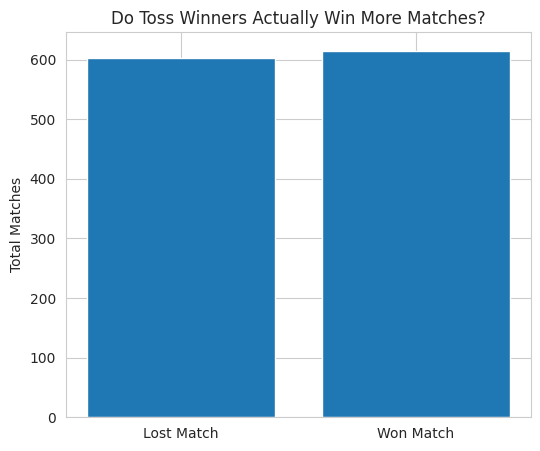

In [6]:
match_df['toss_match_win'] = (
    match_df['toss_winner'] == match_df['winner']
)

toss_win_rate = (
    match_df['toss_match_win'].mean()
) * 100

print(f"🏆 Toss Winners Match Win Rate: {toss_win_rate:.2f}%")

plt.figure(figsize=(6,5))

toss_counts = match_df['toss_match_win'].value_counts()

plt.bar(
    ['Lost Match', 'Won Match'],
    [toss_counts[False], toss_counts[True]]
)

plt.title("Do Toss Winners Actually Win More Matches?")
plt.ylabel("Total Matches")

plt.savefig(
    "chart_toss_impact.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

          phase  total_runs  total_wickets  total_balls  runs_per_ball
0   Death Overs      104595           5285        65818       1.589155
1  Middle Overs      170080           5590       132841       1.280328
2     Powerplay      117444           3531        91014       1.290395


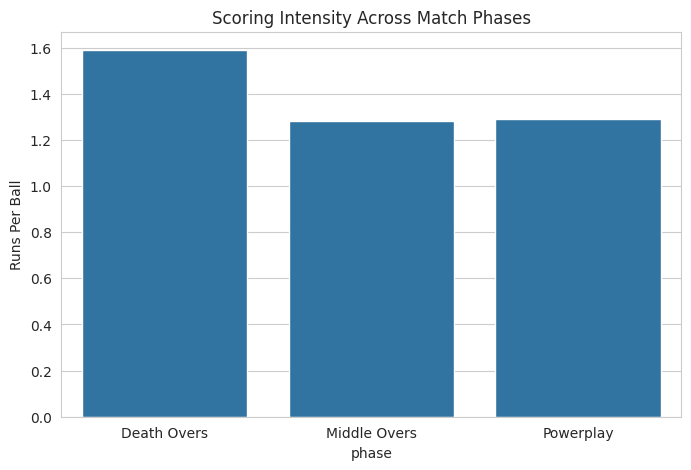

In [7]:
def phase_mapper(over):

    if over <= 6:
        return 'Powerplay'

    elif over <= 15:
        return 'Middle Overs'

    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(phase_mapper)

phase_analysis = df.groupby('phase').agg(
    total_runs=('runs_total', 'sum'),
    total_wickets=('wicket_kind', lambda x: x.notna().sum()),
    total_balls=('ball', 'count')
).reset_index()

phase_analysis['runs_per_ball'] = (
    phase_analysis['total_runs']
    / phase_analysis['total_balls']
)

print(phase_analysis)

plt.figure(figsize=(8,5))

sns.barplot(
    data=phase_analysis,
    x='phase',
    y='runs_per_ball'
)

plt.title("Scoring Intensity Across Match Phases")
plt.ylabel("Runs Per Ball")

plt.savefig(
    "chart_phase_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

   over  wickets  extras  balls  extras_per_100
0    16      828     968  14309        6.764973
1    17      867    1093  14052        7.778252
2    18     1060    1151  13633        8.442749
3    19     1092    1154  12799        9.016329
4    20     1438    1189  11025       10.784580


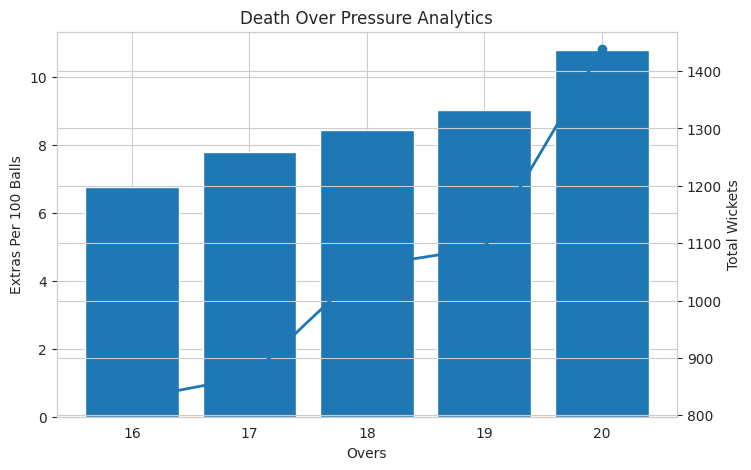

In [8]:
death_overs = df[df['over'] >= 16]

death_analysis = death_overs.groupby('over').agg(
    wickets=('wicket_kind', lambda x: x.notna().sum()),
    extras=('runs_extras', 'sum'),
    balls=('ball', 'count')
).reset_index()

death_analysis['extras_per_100'] = (
    death_analysis['extras']
    / death_analysis['balls']
) * 100

print(death_analysis)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(
    death_analysis['over'],
    death_analysis['extras_per_100']
)

ax2 = ax1.twinx()

ax2.plot(
    death_analysis['over'],
    death_analysis['wickets'],
    marker='o',
    linewidth=2
)

ax1.set_xlabel("Overs")
ax1.set_ylabel("Extras Per 100 Balls")
ax2.set_ylabel("Total Wickets")

plt.title("Death Over Pressure Analytics")

plt.savefig(
    "chart_death_overs.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

                        venue  season_phase  total_matches  chasing_wins  \
25               Eden Gardens  Early Season             44            21   
26               Eden Gardens   Late Season             33            10   
29           Feroz Shah Kotla  Early Season             34             7   
30           Feroz Shah Kotla   Late Season             26            12   
40      M Chinnaswamy Stadium  Early Season             31            11   
41      M Chinnaswamy Stadium   Late Season             34            20   
102          Wankhede Stadium  Early Season             34            14   
103          Wankhede Stadium   Late Season             39            12   
104  Wankhede Stadium, Mumbai  Early Season             39            21   
105  Wankhede Stadium, Mumbai   Late Season             19             8   

     chase_win_rate  
25        47.727273  
26        30.303030  
29        20.588235  
30        46.153846  
40        35.483871  
41        58.823529  
102      

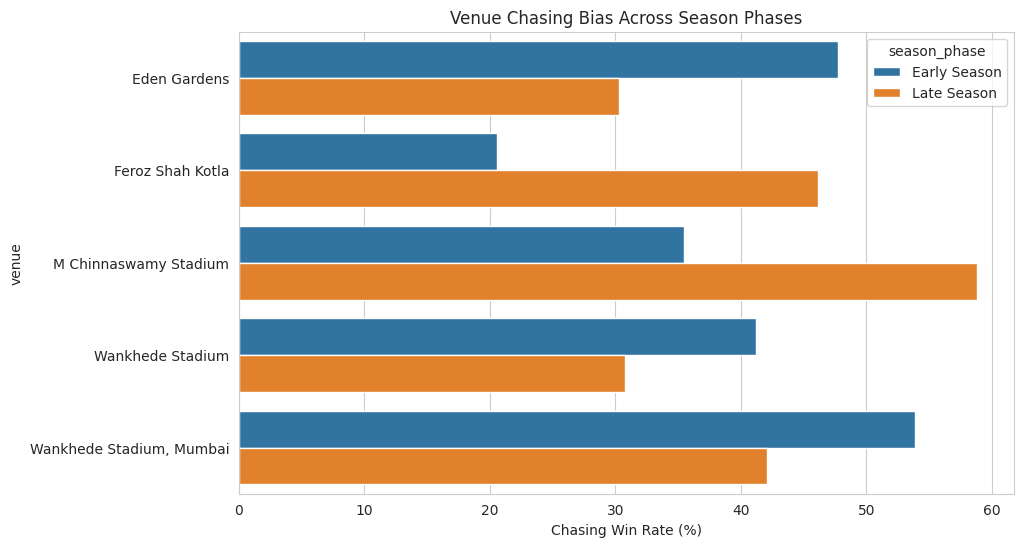

In [9]:
match_df['month'] = match_df['date'].dt.month

match_df['season_phase'] = np.where(
    match_df['month'] <= 4,
    'Early Season',
    'Late Season'
)

match_df['chasing_win'] = np.where(
    match_df['toss_decision'] == 'field',
    match_df['winner'] == match_df['toss_winner'],
    False
)

venue_analysis = match_df.groupby(
    ['venue', 'season_phase']
).agg(
    total_matches=('match_id', 'count'),
    chasing_wins=('chasing_win', 'sum')
).reset_index()

venue_analysis['chase_win_rate'] = (
    venue_analysis['chasing_wins']
    / venue_analysis['total_matches']
) * 100

top_venues = (
    venue_analysis.groupby('venue')['total_matches']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

venue_analysis = venue_analysis[
    venue_analysis['venue'].isin(top_venues)
]

print(venue_analysis)

plt.figure(figsize=(10,6))

sns.barplot(
    data=venue_analysis,
    x='chase_win_rate',
    y='venue',
    hue='season_phase'
)

plt.title("Venue Chasing Bias Across Season Phases")
plt.xlabel("Chasing Win Rate (%)")

plt.savefig(
    "chart_venue_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

             batter  total_runs  balls  dot_balls  boundaries  \
686         V Kohli        9050   6942       2407        1123   
525       RG Sharma        7269   5605       2200         977   
561        S Dhawan        6769   5483       2136         921   
158       DA Warner        6567   4849       1873         899   
310        KL Rahul        5680   4205       1466         729   
595        SK Raina        5536   4177       1476         710   
408        MS Dhoni        5439   4101       1481         639   
51        AM Rahane        5237   4296       1630         661   
31   AB de Villiers        5181   3487       1115         667   
623       SV Samson        5106   3721       1342         661   

     dot_ball_avoidance  boundary_reliance  
686           65.326995          16.176894  
525           60.749331          17.430865  
561           61.043225          16.797374  
158           61.373479          18.539905  
310           65.136742          17.336504  
595           

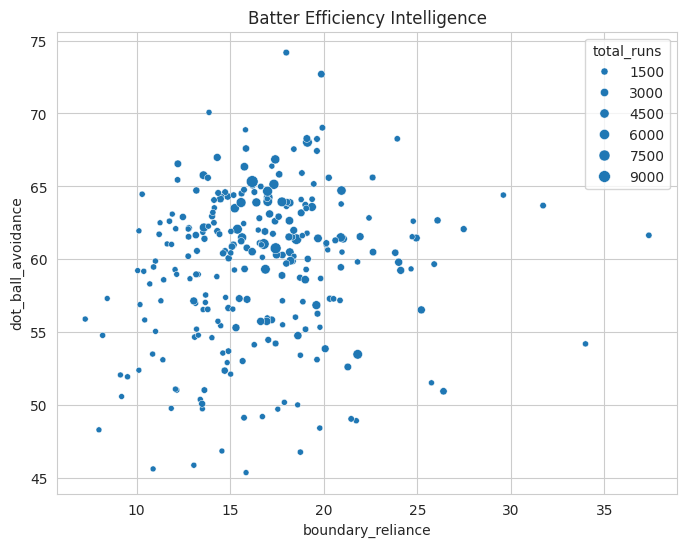

In [10]:
batter_stats = df.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls=('ball', 'count'),
    dot_balls=('runs_batter', lambda x: (x == 0).sum()),
    boundaries=('runs_batter', lambda x: x.isin([4,6]).sum())
).reset_index()

batter_stats = batter_stats[
    batter_stats['balls'] >= 150
]

batter_stats['dot_ball_avoidance'] = (
    1 - (
        batter_stats['dot_balls']
        / batter_stats['balls']
    )
) * 100

batter_stats['boundary_reliance'] = (
    batter_stats['boundaries']
    / batter_stats['balls']
) * 100

top_batters = batter_stats.sort_values(
    by='total_runs',
    ascending=False
).head(10)

print(top_batters)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=batter_stats,
    x='boundary_reliance',
    y='dot_ball_avoidance',
    size='total_runs'
)

plt.title("Batter Efficiency Intelligence")

plt.savefig(
    "chart_batter_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

         bowler  wickets  total_runs  balls   economy
563   YS Chahal      238        5402   4099  7.907294
76      B Kumar      231        5808   4596  7.582245
477   SP Narine      223        5244   4610  6.825163
130    DJ Bravo      207        4436   3296  8.075243
212   JJ Bumrah      207        4497   3715  7.262988
384    R Ashwin      205        5721   4868  7.051356
372   PP Chawla      201        5179   3895  7.977920
469  SL Malinga      188        3486   2974  7.032952
402   RA Jadeja      186        5418   4261  7.629195
8      A Mishra      183        4193   3444  7.304878


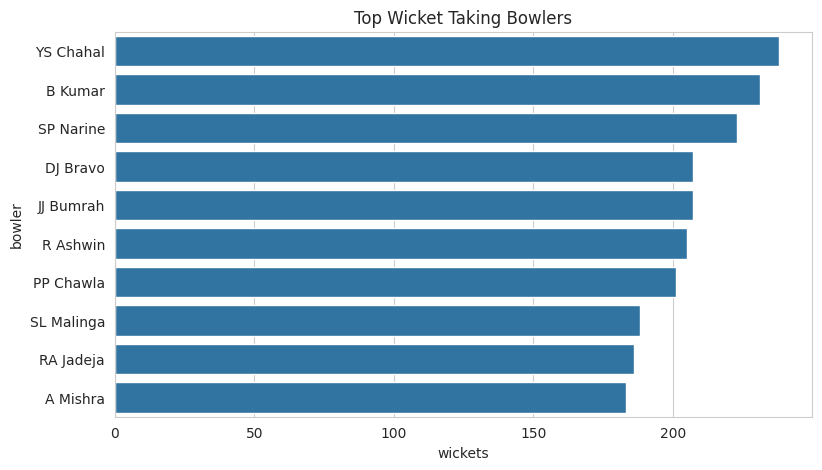

In [11]:
bowler_stats = df.groupby('bowler').agg(
    wickets=('wicket_kind', lambda x: x.notna().sum()),
    total_runs=('runs_total', 'sum'),
    balls=('ball', 'count')
).reset_index()

bowler_stats = bowler_stats[
    bowler_stats['balls'] >= 120
]

bowler_stats['economy'] = (
    bowler_stats['total_runs']
    / (bowler_stats['balls'] / 6)
)

top_bowlers = bowler_stats.sort_values(
    by='wickets',
    ascending=False
).head(10)

print(top_bowlers)

plt.figure(figsize=(9,5))

sns.barplot(
    data=top_bowlers,
    x='wickets',
    y='bowler'
)

plt.title("Top Wicket Taking Bowlers")

plt.savefig(
    "chart_bowler_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()